# Анализ поведения клиентов и транзакционной активности платформ

## 1. Загрузка и подготовка данных
> *В этом разделе данные загружаются из локальных источников, объединяются и проверяются на целостность.*

In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [134]:
# загрузка данных
logs = pd.read_csv(r'data/logs.csv')
user_data = pd.read_csv(r'data/user_data.csv')

In [135]:
# Размер данных (строки, столбцы)
print(f"logs: {logs.shape}")
print(f"user_data: {user_data.shape}")

logs: (4500, 4)
user_data: (2954, 3)


In [136]:
# Типы данных
print("logs:\n", logs.dtypes)
print("\nuser_data:\n", user_data.dtypes)

logs:
 client       int64
success       bool
platform    object
time         int64
dtype: object

user_data:
 client     int64
premium     bool
age        int64
dtype: object


In [137]:
# Количество пропущенных значений
print(f"logs: {logs.isna().sum().sum()} пропусков")
print(f"user_data: {user_data.isna().sum().sum()} пропусков")

logs: 0 пропусков
user_data: 0 пропусков


In [138]:
# Статистика
print("logs:\n", logs.describe())
print("\nuser_data:\n", user_data.describe())

logs:
              client          time
count   4500.000000  4.500000e+03
mean   50998.758000  1.585440e+09
std    28374.472495  2.314866e+04
min       40.000000  1.585400e+09
25%    27056.500000  1.585420e+09
50%    52659.000000  1.585440e+09
75%    76001.250000  1.585461e+09
max    99993.000000  1.585480e+09

user_data:
              client          age
count   2954.000000  2954.000000
mean   50767.886594    44.196005
std    28800.505847    14.248336
min       40.000000    20.000000
25%    25639.500000    32.000000
50%    51569.500000    44.000000
75%    75963.250000    56.000000
max    99973.000000    69.000000


In [139]:
# Данные о платформах
print(f"Уникальных платформ: {logs['platform'].nunique()}")
print(f"Список: {logs['platform'].unique().tolist()}")

Уникальных платформ: 3
Список: ['phone', 'computer', 'tablet']


In [140]:
# проверка потери клиентов
lost = set(logs['client']) - set(user_data['client'])
print(f"\nКлиентов без профиля: {len(lost)}")


Клиентов без профиля: 1057


In [141]:
# Объединение таблиц
full_df = pd.merge(logs, user_data, how = 'inner',on = ['client'])

## 2. Исследовательский анализ данных (EDA)

### 2.1. Идентификация аномальной клиентской активности
> *Поиск пользователей с аномально высоким количеством успешных операций.*

In [142]:
# Фильтруем только успешные транзакции
group_client_success = full_df[full_df['success']==True]

In [143]:
# считаем успешные операции на клиента
group_client_success = group_client_success.groupby('client')['success'].count().reset_index()

In [144]:
# Группируем по количеству операций и формируем список клиентов для каждого значения
top_clients_grouped = group_client_success.groupby('success').agg(
    client_list =('client', lambda x : ', '.join(map(str, sorted(x))))
).reset_index()

In [145]:
top_clients_grouped

,success,client_list
0,1,"40, 75, 81, 132, 164, 278, 316, 405, 492, 624,..."
1,2,"2249, 3936, 6888, 8910, 12438, 13204, 17476, 1..."
2,3,79320
3,40,64064
4,41,"12179, 28719, 36165, 52870, 61468, 61473, 7834..."


In [146]:
# Автоматически находим максимальное число операций
max_success_value = top_clients_grouped['success'].max()
top_client = top_clients_grouped[top_clients_grouped['success'] == max_success_value]
top_client = top_client['client_list'].iloc[0]

In [147]:
print(f'Клиенты с наибольшим количеством заказов: {top_client}')

Клиенты с наибольшим количеством заказов: 12179, 28719, 36165, 52870, 61468, 61473, 78349, 82563, 92584


## **Вывод:** 
Клиенты 12179, 28719, 36165, 52870, 61468, 61473, 78349, 82563, 92584 совершили по 41 успешной операции — это лидеры.

### 2.2. Сравнительный анализ популярности платформ
> *Определение ключевых каналов совершения операций, в том числе для премиум-сегмента.*

In [148]:
# Анализ общей популярности платформ среди успешных операций
top_platform = full_df[full_df['success'] == 1]
top_platform = top_platform.groupby('platform')['success'].count().reset_index().sort_values(by='success', ascending=False)

In [149]:
top1_platform = top_platform['platform'].iloc[0]
top_value     = top_platform['success'].iloc[0]
print(f'Топ 1 платформа "{top1_platform}" на ней было сделано {top_value} - заказов')

Топ 1 платформа "phone" на ней было сделано 1565 - заказов


In [150]:
top_platform

,platform,success
1,phone,1565
0,computer,843
2,tablet,139


## **Вывод:** 
Платформа `phone` лидирует с большим отрывом — 1565 успешные заказов.

In [151]:
# Анализ предпочтений строго премиум-клиентов
premium_platform = full_df[(full_df['premium'] == 1)  & (full_df['success'] == True)]

In [152]:
premium_platform = premium_platform.groupby('platform')['success'].count().reset_index()

In [153]:
premium_platform

,platform,success
0,computer,108
1,phone,177
2,tablet,18


In [154]:
top1_premium_platform = premium_platform['platform'].iloc[0]
top_success_count = premium_platform['success'].iloc[0]
print(f'Самая популярная платформа "{top1_premium_platform}" на ней было зарегистрировано - {top_success_count} пользователя')

Самая популярная платформа "computer" на ней было зарегистрировано - 108 пользователя


## **Вывод:** 
Среди премиум-клиентов платформа `phone` также лидирует (242 уникальных пользователя).

### 2.3. Анализ демографической структуры пользователей
> *Визуализация распределения возраста клиентов в зависимости от их уровня лояльности (премиум/обычный).*

In [155]:
df_plot = full_df.copy()

In [156]:
df_plot['premium'] = df_plot['premium'].map({True : 'Премиальные_клиенты',False : 'Обычные_клиенты'})

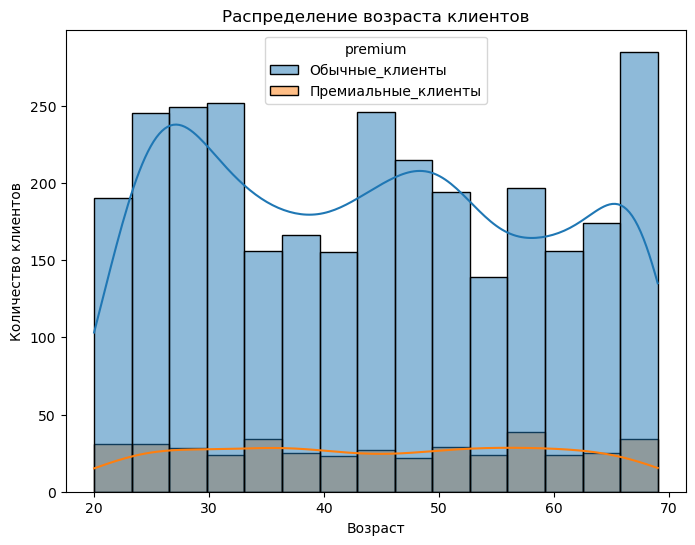

In [157]:
plt.figure(figsize=(8,6))
sns.histplot(df_plot, x = 'age', hue= 'premium', kde=True, stat='count')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.savefig('images/age_distribution_by_premium.png', dpi=300, bbox_inches='tight')

## **Вывод:**
 Премиум-клиенты (оранжевый цвет): Распределены по возрасту очень равномерно от 20 до 68 лет. Явных пиков или перекосов в какую-то одну возрастную группу нет. Продукт интересен премиум-пользователям любого возраста.
 
 
 Обычные клиенты (синий цвет): Здесь распределение волнообразное. Четко видны три группы активности: молодые люди (25–30 лет), клиенты среднего возраста (около 45 лет) и самый высокий пик — пожилые люди (старше 65 лет).

### 2.4. Анализ распределения транзакционной активности
> *Изучение частоты успешных операций на одного клиента и выявление скрытых аномалий.*

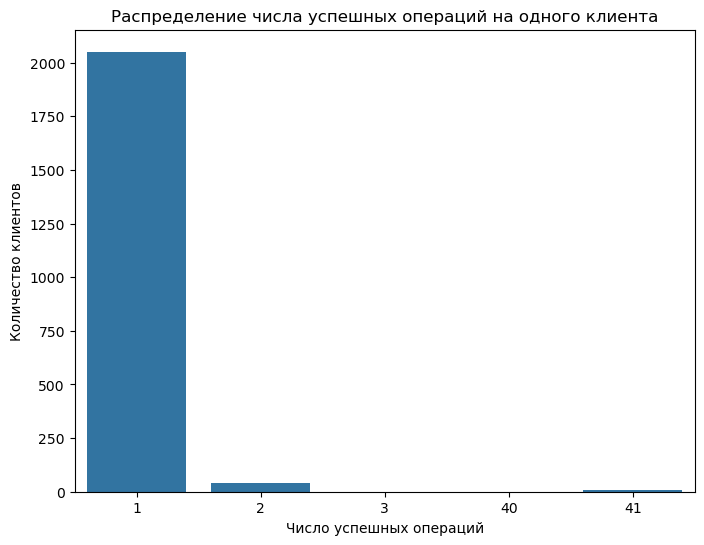

In [158]:
plt.figure(figsize=(8,6))
sns.countplot(group_client_success, x ='success')
plt.title('Распределение числа успешных операций на одного клиента')
plt.xlabel('Число успешных операций')
plt.ylabel('Количество клиентов')
plt.savefig('images/success_operations_distribution.png', dpi=300, bbox_inches='tight')

## Вывод:

Подавляющее большинство клиентов (более 2000 человек) совершают всего по 1–2 успешные операции. Это основная масса пользователей платформы.

Обнаружена группа аномально активных клиентов: в данных присутствует небольшое число пользователей (9 человек), каждый из которых совершил ровно 41 успешную операцию.

Промежуточные значения отсутствуют: на отрезках от 3 до 40 операций активность пользователей практически нулевая.

### 2.5. Детальный анализ десктопного сегмента (Задание 6)
> *Изучение возрастной структуры пользователей, совершающих успешные действия на платформе Computer.*

In [159]:
df_plot_computer = full_df

In [160]:
# Фильтруем данные по платформе computer и успешным действиям
df_plot_computer = df_plot_computer[(df_plot_computer['platform']== 'computer') & (df_plot_computer['success']== True)]

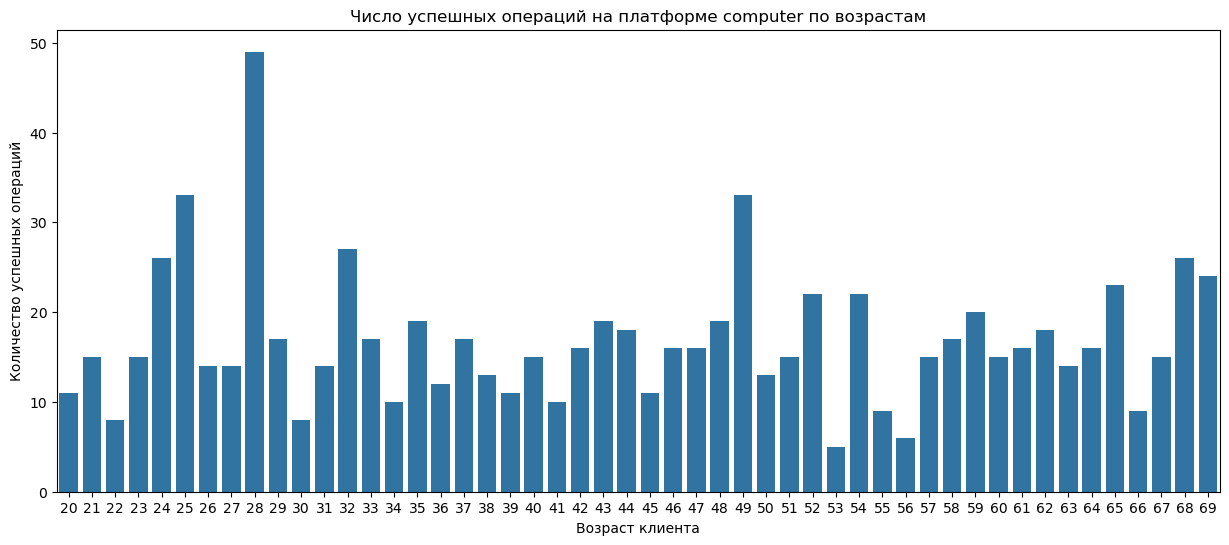

In [161]:
plt.figure(figsize=(15,6))
sns.countplot(df_plot_computer, x='age')
plt.title('Число успешных операций на платформе computer по возрастам')
plt.xlabel('Возраст клиента')
plt.ylabel('Количество успешных операций')
plt.savefig('images/computer_operations_by_age.png', dpi=300, bbox_inches='tight')

## Вывод:

Абсолютный лидер по активности: Максимальное количество успешных операций на компьютерах совершают клиенты в возрасте 28 лет (выраженный пик, около 49 операций).

Дополнительные пики активности: Также повышенный интерес к платформе заметен у молодых людей в возрасте 25 лет и зрелых клиентов в возрасте 49 лет (оба пика — выше 30 операций).

Общая тенденция: В остальных возрастных группах (как среди молодых, так и среди пожилых) активность держится на стабильном среднем уровне — примерно от 10 до 20 успешных операций для каждого возраста.